## 1. Project Title
### Predictive Forecasting of Care Load & Placement Demand

#### The project uses historical daily data to predict:

##### * Future children in HHS care
##### * Future transfers into HHS care
##### * Future discharge/placement demand
##### * Possible capacity pressure

##### The main purpose is to help planners prepare resources in advance instead of reacting after demand increases.

## 2. Background and Context

#### The document explains that the UAC program operates in an uncertain environment.

#### Events such as:

##### * Changes in border activity
##### * Policy changes
##### * Humanitarian situations
##### * Changes in transfers
##### * Changes in discharge rates

##### can cause the number of children requiring care to change quickly.

##### Traditional analytics tells us:

##### What happened?

##### Predictive analytics tries to answer:

##### What is likely to happen next?

##### That is why forecasting is important.

## 3. Problem Statement

#### The current system has historical daily data, but it does not sufficiently provide:

##### * Short-term care-load forecasts
##### * Future discharge/placement demand
##### * Early warnings about capacity pressure

##### Without forecasting, organizations may react too late.

#####  Possible operational consequences include:

##### * Overcrowding
##### * Staff workload
##### * Resource shortages
##### * Longer stays

## 4. Project Workflow

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
import joblib
from sklearn.model_selection import train_test_split

In [2]:
healthcare = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program.csv")

In [3]:
healthcare.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6,18,11,"2,484",14
1,"December 18, 2025",11,50,6,"2,472",16
2,"December 17, 2025",7,31,11,"2,481",10
3,"December 16, 2025",8,54,15,"2,468",9
4,"December 15, 2025",11,42,9,"2,470",7


In [4]:
healthcare.shape

(720, 6)

In [5]:
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             720 non-null    object
 1   Children apprehended and placed in CBP custody*  720 non-null    int64 
 2   Children in CBP custody                          720 non-null    int64 
 3   Children transferred out of CBP custody          720 non-null    int64 
 4   Children in HHS Care                             720 non-null    object
 5   Children discharged from HHS Care                720 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 33.9+ KB


In [6]:
healthcare.columns =(healthcare.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_"))
print(healthcare.columns)

Index(['date', 'children_apprehended_and_placed_in_cbp_custody*',
       'children_in_cbp_custody', 'children_transferred_out_of_cbp_custody',
       'children_in_hhs_care', 'children_discharged_from_hhs_care'],
      dtype='object')


In [7]:
healthcare["date"] = pd.to_datetime(healthcare["date"])
healthcare =healthcare.sort_values("date")
healthcare = healthcare.set_index("date")
healthcare.head()

,children_apprehended_and_placed_in_cbp_custody*,children_in_cbp_custody,children_transferred_out_of_cbp_custody,children_in_hhs_care,children_discharged_from_hhs_care
date,,,,,
2023-01-12,33,53,34,"6,566",436
2023-01-22,32,49,39,"7,122",227
2023-01-23,32,50,39,"7,280",181
2023-01-24,47,42,47,"7,433",175
2023-01-25,20,22,41,"7,538",180


In [8]:
healthcare.isnull().sum()

children_apprehended_and_placed_in_cbp_custody*    0
children_in_cbp_custody                            0
children_transferred_out_of_cbp_custody            0
children_in_hhs_care                               0
children_discharged_from_hhs_care                  0
dtype: int64

In [9]:
missing = healthcare.isnull().mean()*100
print(missing)

children_apprehended_and_placed_in_cbp_custody*    0.0
children_in_cbp_custody                            0.0
children_transferred_out_of_cbp_custody            0.0
children_in_hhs_care                               0.0
children_discharged_from_hhs_care                  0.0
dtype: float64


In [10]:
healthcare.index.duplicated().sum()

np.int64(0)

In [11]:
healthcare = healthcare[~healthcare.index.duplicated(keep="first")]

In [12]:
full_date = pd.date_range(start=healthcare.index.min(), end= healthcare.index.max(), freq="D")
healthcare = healthcare.reindex(full_date)
healthcare.index.name = "date"
healthcare.isnull().sum()


children_apprehended_and_placed_in_cbp_custody*    355
children_in_cbp_custody                            355
children_transferred_out_of_cbp_custody            355
children_in_hhs_care                               355
children_discharged_from_hhs_care                  355
dtype: int64

In [13]:
numeric_colums = healthcare.select_dtypes(include=np.number).columns
healthcare[numeric_colums] = healthcare[numeric_colums].interpolate(method="time")

In [14]:
healthcare = healthcare.ffill().bfill()

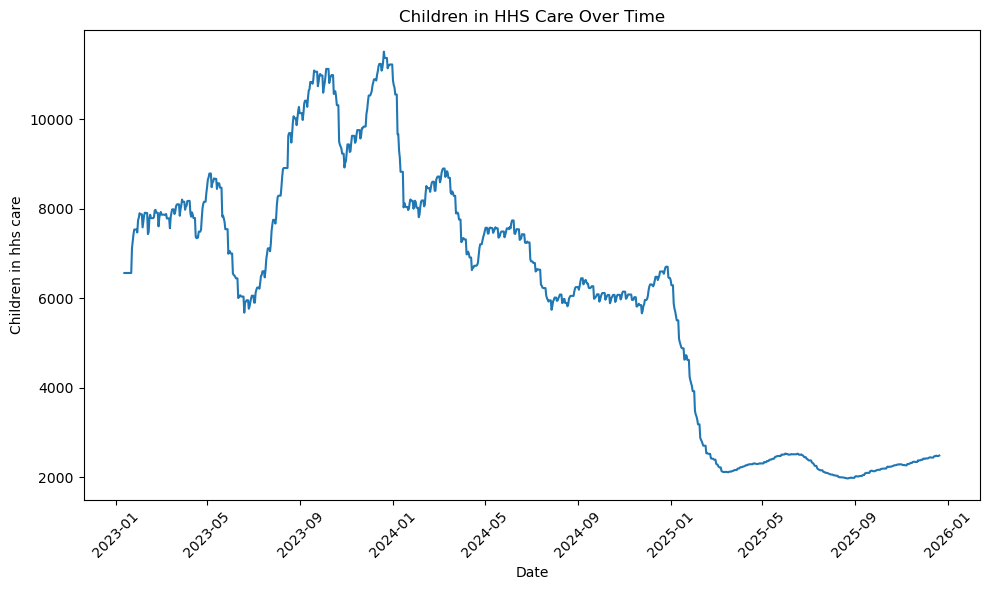

In [15]:
plt.figure(figsize=(10,6))
plt.plot(healthcare.index,pd.to_numeric(healthcare["children_in_hhs_care"].astype(str).str.replace(",", ""),errors="coerce"))
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children in hhs care")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

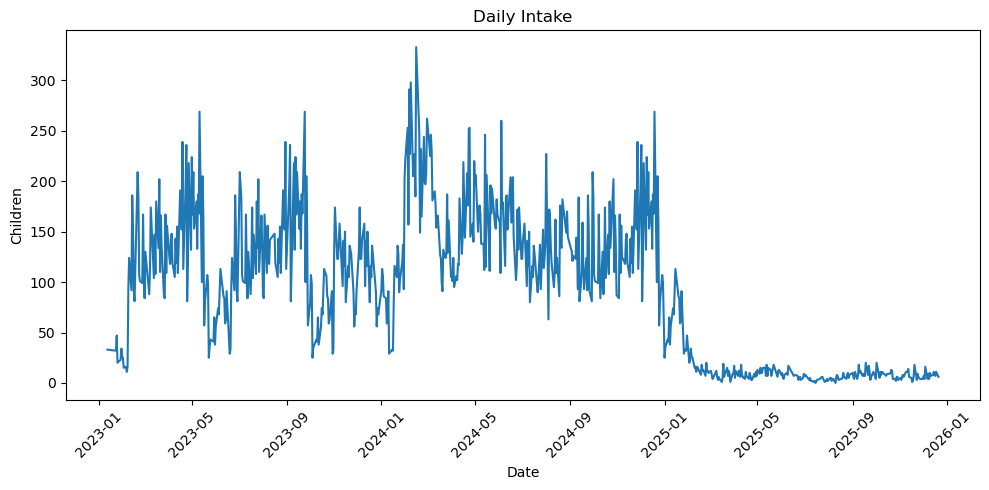

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(healthcare.index,pd.to_numeric(healthcare["children_apprehended_and_placed_in_cbp_custody*"],errors="coerce"))
plt.title("Daily Intake")
plt.xlabel("Date")
plt.ylabel("Children")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

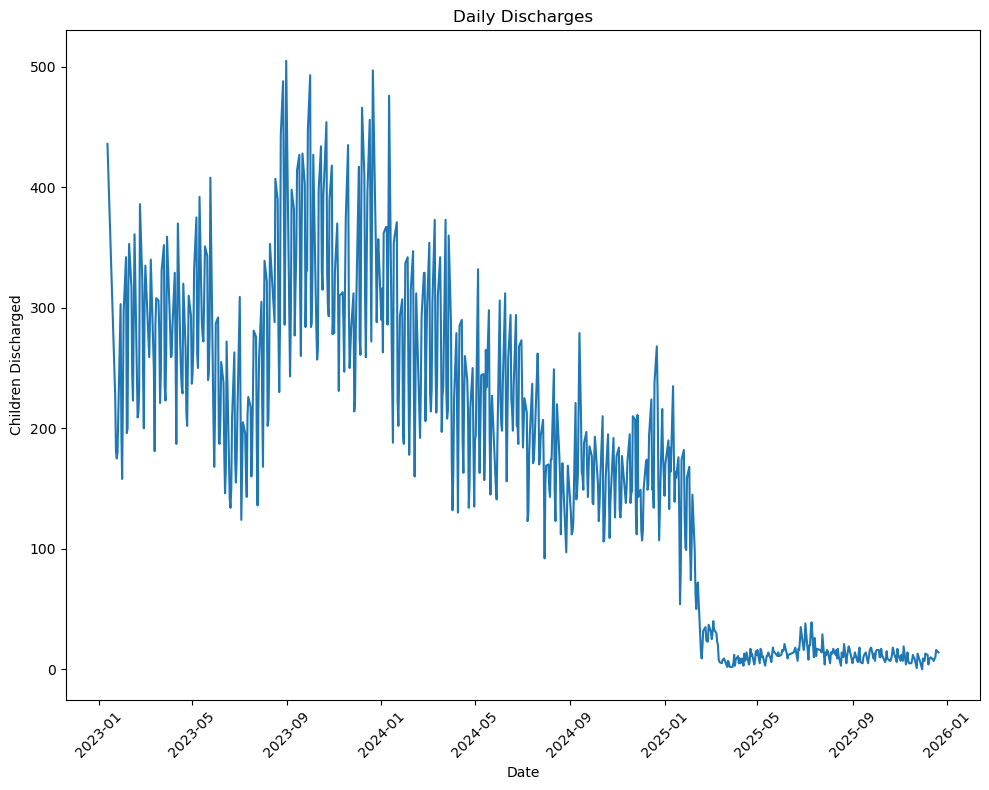

In [17]:
plt.figure(figsize=(10,8))
plt.plot(healthcare.index, pd.to_numeric (healthcare["children_discharged_from_hhs_care"],errors="coerce"))
plt.title("Daily Discharges")
plt.xlabel("Date")
plt.ylabel("Children Discharged")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
healthcare["net_pressure"] = (healthcare["children_transferred_out_of_cbp_custody"] - healthcare["children_discharged_from_hhs_care"])

In [19]:
healthcare["core_load_change"] = ( healthcare ["children_in_hhs_care"].diff)

In [20]:
healthcare["lag_1"] = (healthcare["children_in_hhs_care"].shift(1))
healthcare["lag_7"] = healthcare["children_in_hhs_care"].shift(7)
healthcare["lag_14"] = (healthcare["children_in_hhs_care"].shift(14))

In [21]:
healthcare["children_in_hhs_care"] = pd.to_numeric(
    healthcare["children_in_hhs_care"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

healthcare["core_load_change"] = healthcare["children_in_hhs_care"].diff()
healthcare["lag_1"] = healthcare["children_in_hhs_care"].shift(1)
healthcare["lag_7"] = healthcare["children_in_hhs_care"].shift(7)
healthcare["lag_14"] = healthcare["children_in_hhs_care"].shift(14)

healthcare["rolling_mean_7"] = healthcare["children_in_hhs_care"].rolling(7).mean()
healthcare["rolling_mean_14"] = (healthcare["children_in_hhs_care"].rolling(14).mean())
healthcare["rolling_mean_7"] = (healthcare["children_in_hhs_care"].rolling(7).std())

In [22]:
healthcare["day_of_week"] = healthcare.index.dayofweek
healthcare["month"] = healthcare.index.month
healthcare["day"] = healthcare.index.day
healthcare["is_weekend"] = (healthcare["day_of_week"]>=5).astype(int)

In [23]:
healthcare = healthcare.dropna()

In [24]:
healthcare.head()

,children_apprehended_and_placed_in_cbp_custody*,children_in_cbp_custody,children_transferred_out_of_cbp_custody,children_in_hhs_care,children_discharged_from_hhs_care,net_pressure,core_load_change,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,day_of_week,month,day,is_weekend
date,,,,,,,,,,,,,,,,
2023-01-26,20.75,27.75,33.5,7538,210.75,-177.25,0.0,7538.0,6566.0,6566.0,424.453767,6857.500000,3,1,26,0
2023-01-27,21.50,33.50,26.0,7538,241.50,-215.50,0.0,7538.0,6566.0,6566.0,355.300074,6926.928571,4,1,27,0
2023-01-28,22.25,39.25,18.5,7538,272.25,-253.75,0.0,7538.0,6566.0,6566.0,165.304481,6996.357143,5,1,28,1
2023-01-29,23.00,45.00,11.0,7472,303.00,-292.00,-66.0,7538.0,7122.0,6566.0,96.309768,7061.071429,6,1,29,1
2023-01-30,34.00,54.00,29.0,7743,196.00,-167.00,271.0,7472.0,7280.0,6566.0,97.673655,7145.142857,0,1,30,0


In [25]:
healthcare.shape

(1061, 16)

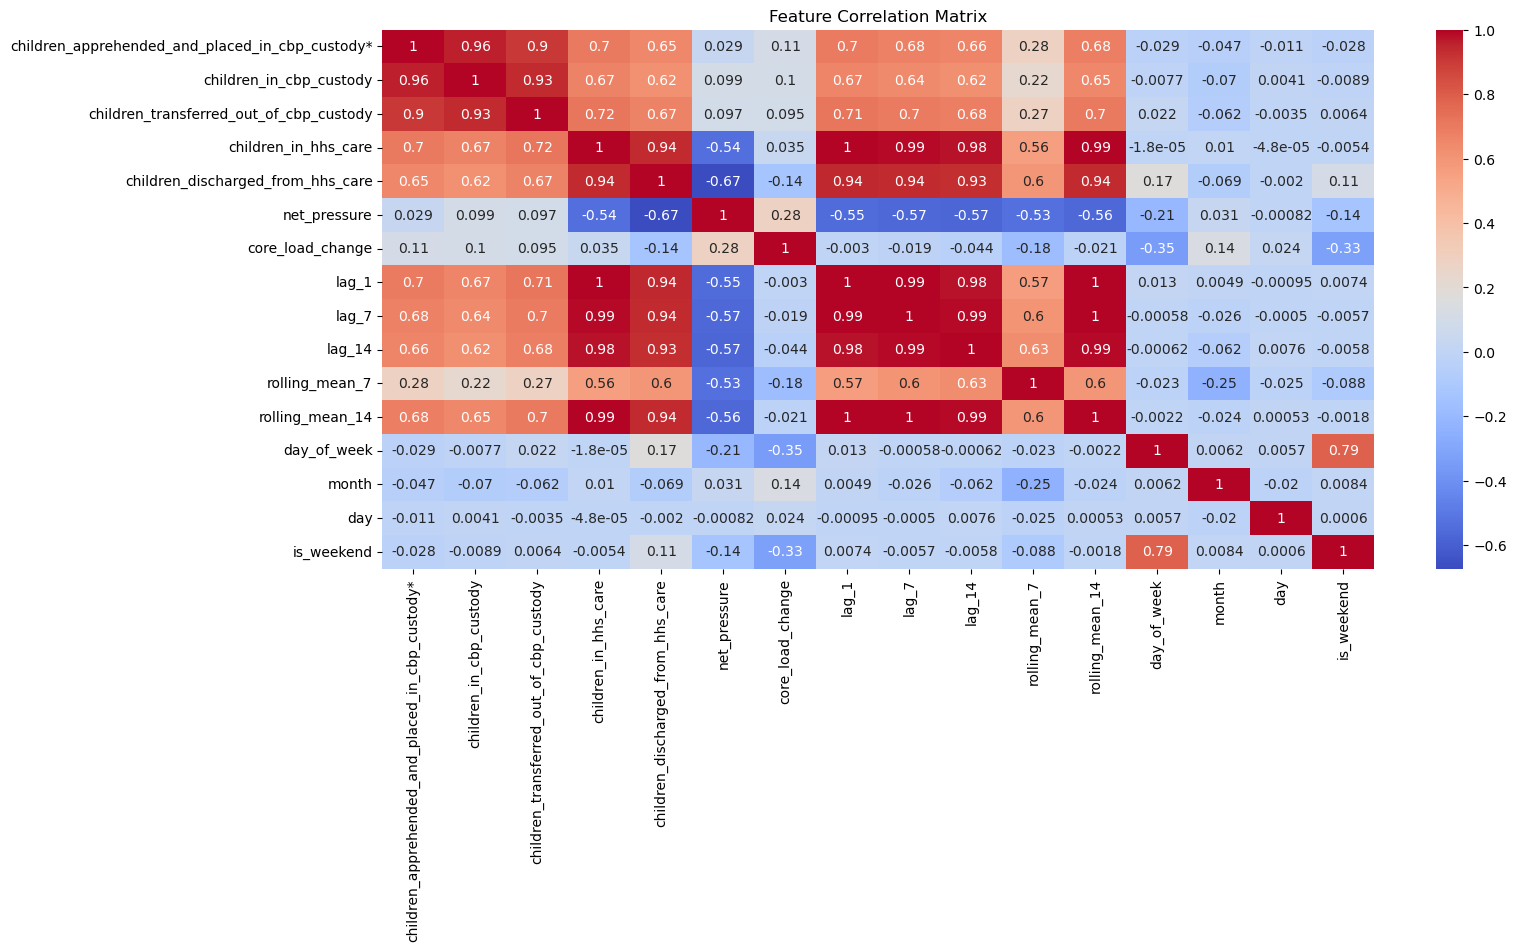

In [26]:
plt.figure(figsize=(16,7))
correlation = healthcare.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [27]:
target = "children_in_hhs_care"
X = healthcare.drop(columns=[target])
y = healthcare[target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.80, test_size=0.20)

In [29]:
split_index = int(len(healthcare) * 0.80)
X_train =X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (848, 15)
Testing: (213, 15)


In [30]:
naive_predictions = y_test.shift(1)

In [31]:
naive_predictions.iloc[0] = y_train.iloc[-1]

In [32]:
mae = mean_absolute_error(y_test, naive_predictions)

In [33]:
print("\n Naive MAE :", mae)


 Naive MAE : 6.652582159624413


In [34]:
rmse = np.sqrt(mean_squared_error(y_test, naive_predictions))

In [35]:
print("\n Naive RMSE :", rmse)


 Naive RMSE : 11.34168430247031


In [36]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true !=0
    return np.mean(np.abs((y_true[mask]-y_pred[mask])/ y_true[mask]))*100

In [37]:
print("\n MAPE:", mape(y_test, naive_predictions))


 MAPE: 0.29509254168878213


In [38]:
features = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_14", "rolling_std_7", "net_pressure", "day_of_week","month","is_weekend"]

In [39]:
healthcare["rolling_mean_7"] = (
    healthcare[target].rolling(window=7).mean()
)
healthcare["rolling_std_7"] = (
    healthcare[target].rolling(window=7).std()
)

healthcare = healthcare.dropna(subset=features + [target])

X = healthcare[features]
y = healthcare[target]

split_index = int(len(healthcare) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
y = healthcare[target]

split_index = int(len(healthcare) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [40]:
model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42,n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
pred = model.predict(X_test)

In [42]:
mae_1 = mean_absolute_error(y_test, pred)

In [43]:
print("\nRandom Forest MAE:", mae_1)


Random Forest MAE: 44.148867768750456


In [44]:
rmse_1 = np.sqrt(mean_squared_error(y_test, pred))

In [45]:
print("\nRandom Forest RMSE:", rmse_1)



Random Forest RMSE: 66.753582843013


In [46]:
mape_1 = mape(y_test, pred)

In [47]:
print("\nRandom Forest MAPE:", mape_1)


Random Forest MAPE: 2.0935071420411866


In [48]:
gb_model = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05,max_depth=3,random_state=42)

In [ ]:
gb_model.fit(X_train,y_train)

In [ ]:
gb_predictions = gb_model.predict(X_test)

In [ ]:
mae_2 = mean_absolute_error(y_test,gb_predictions)

rmse_2 = np.sqrt(mean_squared_error(y_test,gb_predictions))

mape_2 = mape(y_test,gb_predictions)

print("Gradient Boosting MAE:", mae_2)
print("Gradient Boosting RMSE:", rmse_2)
print("Gradient Boosting MAPE:", mape_2)

Gradient Boosting MAE: 48.66224047469025
Gradient Boosting RMSE: 71.81573816967526
Gradient Boosting MAPE: 2.3295085068928785


In [ ]:
result = pd.DataFrame({
    "model": ["naive","Random Forest","Gradient Boosting"],
    "MAE": [mae,mae_1,mae_2],
    "RMSE": [rmse,rmse_1,rmse_2],
    "MAPE" : [mape,mape_1,mape_2]
})
result

,model,MAE,RMSE,MAPE
0,naive,6.779904,11.449703,<function mape at 0x0000022D0551A3E0>
1,Random Forest,41.014838,65.166582,1.972496
2,Gradient Boosting,48.662240,71.815738,2.329509


In [ ]:
train_series = y.iloc[:split_index]
test_series = y.iloc[split_index:]

In [ ]:
arima_model = ARIMA(train_series, order=(7,1,2))
arima_result = arima_model.fit()

c:\Users\SIMON\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
arima_predictions = arima_result.forecast(steps=len(test_series))

In [ ]:
arima_mae = mean_absolute_error(test_series, arima_predictions)

In [ ]:
print("ARIMA MAE:", arima_mae)

ARIMA MAE: 331.74493249869994


In [ ]:
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_predictions))

In [ ]:
print("ARIMA RMSE:", arima_rmse)

ARIMA RMSE: 378.8735224693386


In [ ]:
arima_mape = mape(test_series,arima_predictions)

In [ ]:
print("ARIMA RMSE:", arima_mape)

ARIMA RMSE: 15.501394013386841


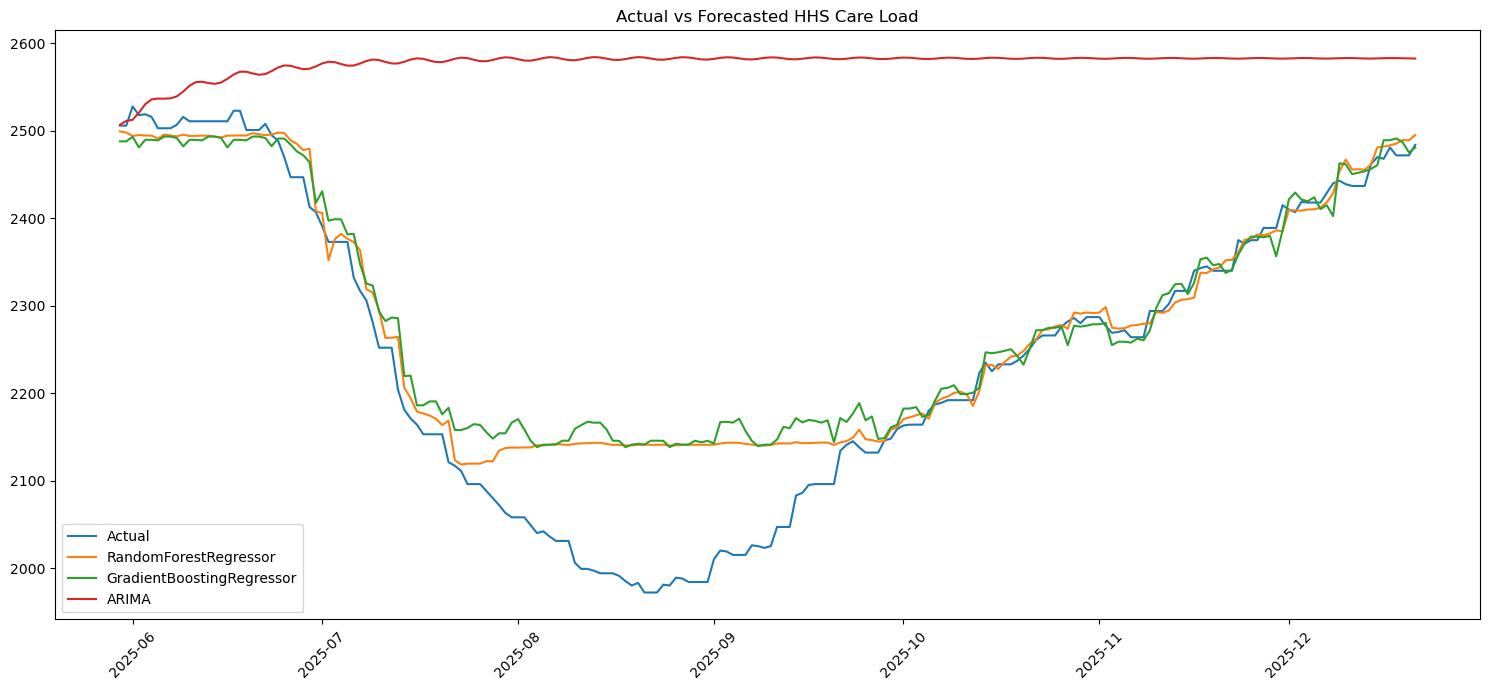

In [ ]:
plt.figure(figsize=(15,7))
plt.plot(test_series.index, test_series, label="Actual")
plt.plot(test_series.index, pred, label = "RandomForestRegressor")
plt.plot(test_series.index, gb_predictions, label="GradientBoostingRegressor")
plt.plot(test_series.index, arima_predictions, label="ARIMA")
plt.title("Actual vs Forecasted HHS Care Load")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})
importance = importance.sort_values("Importance", ascending=False)
importance

,Feature,Importance
0,lag_1,0.556100
3,rolling_mean_7,0.338140
4,rolling_mean_14,0.060500
1,lag_7,0.025930
2,lag_14,0.017606
8,month,0.000495
6,net_pressure,0.000444
5,rolling_std_7,0.000417
7,day_of_week,0.000358
9,is_weekend,0.000010


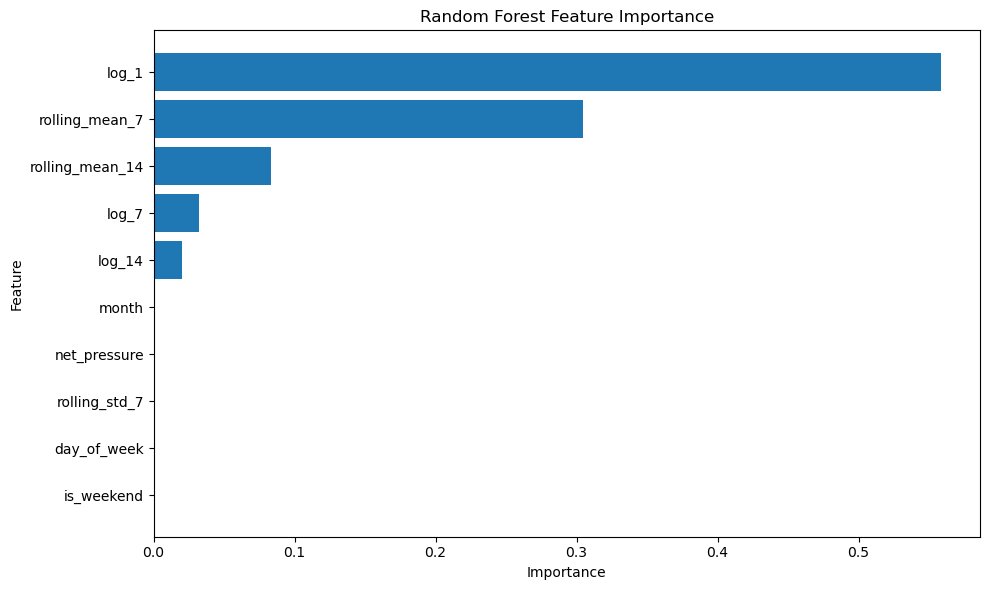

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
def forecast_future(model,data,horizon=14):
    history = data["children_in_hhs_care"].tolist()
    future_predictions = []
    for i in range(horizon):
        lag_1 = history[-1]
        lag_7 = history[-7]
        lag_14 = history[-14]
        rolling_mean_7 = np.mean(history[-7:])
        rolling_mean_14 = np.mean(history[-14:])
        rolling_std_7 = np.std(history[-7:])
        transfer = data["children_transferred_out_of_cbp_custody"].iloc[-1]
        discharge = data["children_discharged_from_hhs_care"].iloc[-1]
        net_pressure = (transfer - discharge)
        next_date = (data.index[-1]+pd.Timedelta(days=i+1))
        day_of_week = next_date.dayofweek
        month = next_date.month
        is_weekend = int(day_of_week>=5)
        row = [[
            lag_1,
            lag_7,
            lag_14,
            rolling_mean_7,
            rolling_mean_14,
            rolling_std_7,
            net_pressure,
            day_of_week,
            month,
            is_weekend

        ]]
        prediction = model.predict(row)[0]
        future_predictions.append(prediction)
        history.append(prediction)
    return future_predictions

In [ ]:
future_predictions = forecast_future(model,healthcare,horizon=14)

c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
future_dates = pd.date_range(start=healthcare.index[-1]+pd.Timedelta(days=1),
                             periods=14,
                             freq="D"
                             )

In [ ]:
future_healt = pd.DataFrame({
    "date": future_dates,
    "predicted_hhs_care": future_predictions
})
future_healt = future_healt.set_index("date")
future_healt

,predicted_hhs_care
date,
2025-12-22,2498.233333
2025-12-23,2500.980000
2025-12-24,2501.166667
2025-12-25,2501.513333
2025-12-26,2499.290000
2025-12-27,2499.570000
2025-12-28,2497.796667
2025-12-29,2497.400000
2025-12-30,2497.503333


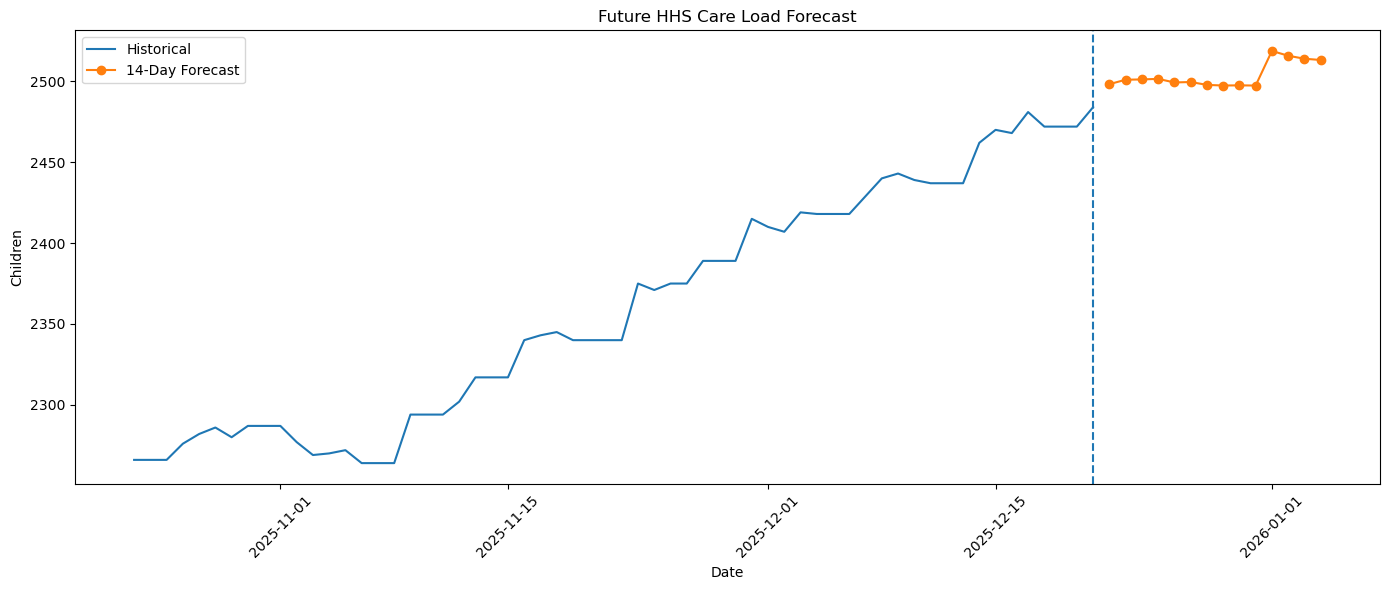

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(healthcare.index[-60:], healthcare["children_in_hhs_care"].iloc[-60:], label="Historical")
plt.plot(future_healt.index, future_healt["predicted_hhs_care"], marker="o", label="14-Day Forecast")
plt.axvline(healthcare.index[-1], linestyle="--")
plt.title("Future HHS Care Load Forecast")
plt.xlabel("Date")
plt.ylabel("Children")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
target_discharge = ("children_discharged_from_hhs_care")

In [ ]:
healthcare["discharge_lag_1"] = (healthcare[target_discharge].shift(1))
healthcare["discharge_lag_7"] = (healthcare[target_discharge].shift(7))
healthcare["discharge_lag_14"] = (healthcare[target_discharge].shift(14))
healthcare["discharge_rolling_7"] = (healthcare[target_discharge].rolling(7).mean())
healthcare["discharge_rolling_14"] = (healthcare[target_discharge].rolling(14).mean())

In [ ]:
discharge_features =[
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "discharge_rolling_7",
    "discharge_rolling_14",
    "children_transferred_out_of_cbp_custody",
    "children_in_hhs_care",
    "net_pressure",
    "day_of_week",
    "month"
]

In [ ]:
discharge_df = healthcare.dropna(subset=discharge_features+[target_discharge])

In [ ]:
X = discharge_df[
    discharge_features
]

y = discharge_df[
    target_discharge
]

split = int(len(discharge_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
discharge_model = RandomForestRegressor(n_estimators=300,max_depth=12,random_state=42,n_jobs=-1)
discharge_model.fit(X_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
discharge_predictions = (discharge_model.predict(X_test))

In [ ]:
print("\n Discharge MAE:", mean_absolute_error(y_test,discharge_predictions))
print("\n Discharge RMSE:", np.sqrt(mean_squared_error(y_test,discharge_predictions)))


 Discharge MAE: 1.9367782351543226

 Discharge RMSE: 2.5365658482536575


In [ ]:
capacity_limit = 1500

future_healt["capacity_breach"] = (
    future_healt["predicted_hhs_care"] >= capacity_limit
)

future_healt

,predicted_hhs_care,capacity_breach
date,,
2025-12-22,2498.233333,True
2025-12-23,2500.980000,True
2025-12-24,2501.166667,True
2025-12-25,2501.513333,True
2025-12-26,2499.290000,True
2025-12-27,2499.570000,True
2025-12-28,2497.796667,True
2025-12-29,2497.400000,True
2025-12-30,2497.503333,True


In [ ]:
future_df_features = []

history = healthcare[target].tolist()
transfer = healthcare["children_transferred_out_of_cbp_custody"].iloc[-1]
discharge = healthcare["children_discharged_from_hhs_care"].iloc[-1]
net_pressure = transfer - discharge

for i, next_date in enumerate(future_dates):
    row = {
        "lag_1": history[-1],
        "lag_7": history[-7],
        "lag_14": history[-14],
        "rolling_mean_7": np.mean(history[-7:]),
        "rolling_mean_14": np.mean(history[-14:]),
        "rolling_std_7": np.std(history[-7:], ddof=1),
        "net_pressure": net_pressure,
        "day_of_week": next_date.dayofweek,
        "month": next_date.month,
        "is_weekend": int(next_date.dayofweek >= 5),
    }

    future_df_features.append(row)
    history.append(future_predictions[i])

future_df_features = pd.DataFrame(future_df_features)[features]

tree_predictions = np.array([
    tree.predict(future_df_features)
    for tree in model.estimators_
])

c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\utils\validati

In [ ]:
lower_boun =np.percentile(tree_predictions,5,axis=0)
upper_bound = np.percentile(tree_predictions,95,axis=0)

In [ ]:
capacity_limit = 1500

In [ ]:
breach_dates = future_healt[
    future_healt["predicted_hhs_care"]
    >= capacity_limit
]

In [ ]:
if len(breach_dates) > 0:

    first_breach = breach_dates.index[0]

    lead_time = (
        first_breach - healthcare.index[-1]
    ).days

    print(
        "Capacity breach expected in:",
        lead_time,
        "days"
    )

else:

    print(
        "No capacity breach in forecast horizon."
    )

Capacity breach expected in: 1 days
